In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Set the random seed for reproducibility and define the dataset size
np.random.seed(42)
N = 1000

In [3]:
# Define pricing factor functions used to compute a synthetic surge multiplier and generate synthetic data

# Increase price during rush hours
def get_peak_factor(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 21:
        return 1.5
    return 1.0
    
# Apply a weather-based multiplier for rain or snow
def get_weather_factor(weather):
    mapping = {
        'clear': 1.0,
        'rain': 1.2,
        'snow': 1.3
    }
    return mapping[weather]

# Map traffic conditions to pricing multipliers
def get_traffic_factor(traffic):
    mapping = {
        'low': 1.0,
        'medium': 1.15,
        'high': 1.3
    }
    return mapping[traffic]

# Base demand grows during busy hours and bad weather
def get_demand_factor(hour, weather):
    base = 1.0
    if 7 <= hour <= 10 or 17 <= hour <= 21:
        base += 0.5
    if weather == 'rain':
        base += 0.2
    elif weather == 'snow':
        base += 0.3

    return base 

 # Combine demand and traffic effects, capping the surge factor
def compute_surge(demand_factor, traffic_factor):  
    surge = demand_factor * traffic_factor
    return min(surge, 2.2)  # Cap surge at 2.2x to prevent unrealistic prices

In [4]:
# Generate synthetic ride features and compute the final fare for each trip

distance = np.random.exponential(scale=10, size=N)  # Average distance of 10 km
distance=np.clip(distance, 1, 40)  # Cap distance to 40 km for realism
hour = np.random.randint(0, 24, N)
weather=np.random.choice(['clear', 'rain', 'snow'], N, p=[0.5, 0.3, 0.2])
traffic = np.random.choice(['low', 'medium', 'high'], N, p=[0.5, 0.3, 0.2])

price = []

for i in range(N):
    # Base fare and per-kilometer rate for each ride
    base_fare = 40
    per_km = 12
    fare = base_fare + per_km * distance[i]

    # Compute all pricing multipliers for this ride
    peak_factor = get_peak_factor(hour[i])
    weather_factor = get_weather_factor(weather[i])
    traffic_factor = get_traffic_factor(traffic[i])
    demand_factor = get_demand_factor(hour[i], weather[i])
    surge = compute_surge(demand_factor, traffic_factor)
    
    # Apply surge pricing and additional multipliers
    fare *= peak_factor
    fare += (weather_factor-1) * 40  # Weather adds a fixed amount to the fare
    fare *= surge

    # Add random noise to simulate real-world fare variation
    noise = np.random.normal(0, 8)    
    fare += noise

    price.append(round(fare, 2))

In [5]:
# Assemble the synthetic dataset into a DataFrame and save it to disk

df = pd.DataFrame({
    'distance': distance,
    'hour': hour,
    'weather': weather,
    'traffic': traffic,
    'price': price
})

df.to_csv('../data/synthetic_rides.csv', index=False)
print("Dataset created and saved as synthetic_rides.csv")

Dataset created and saved as synthetic_rides.csv


In [6]:
# Load the generated dataset and perform a quick quality check

print("Dataset shape:\n", df.shape)
print("\nFirst 5 rows:\n", df.head())

print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:\n", df.duplicated().sum())

print("\nTraffic distribution:\n", df["traffic"].value_counts())
print("\nWeather distribution:\n", df["weather"].value_counts())

Dataset shape:
 (1000, 5)

First 5 rows:
     distance  hour weather traffic   price
0   4.692681    14    rain    high  157.52
1  30.101214    11    snow     low  537.19
2  13.167457    15   clear  medium  228.16
3   9.129426    23    snow  medium  237.42
4   1.696249    18    snow     low  194.16

Missing values:
 distance    0
hour        0
weather     0
traffic     0
price       0
dtype: int64

Duplicate rows:
 0

Traffic distribution:
 traffic
low       499
medium    307
high      194
Name: count, dtype: int64

Weather distribution:
 weather
clear    498
rain     304
snow     198
Name: count, dtype: int64


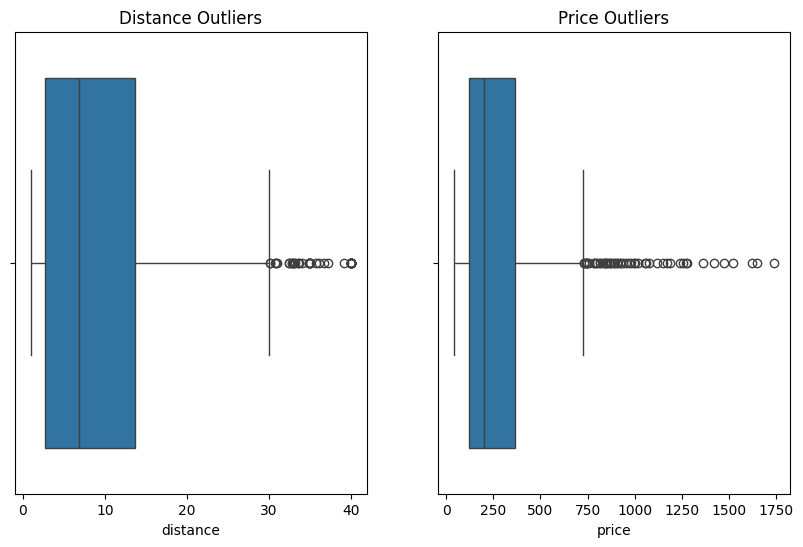

In [7]:
# Visualize the distribution of distance and price to identify potential outliers

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['distance'])
plt.title('Distance Outliers')
plt.savefig('../outputs/plots/distance_outliers.png')  # Save the distance boxplot

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'])
plt.title('Price Outliers')  
plt.savefig('../outputs/plots/price_outliers.png')  # Save the price boxplot
plt.show()


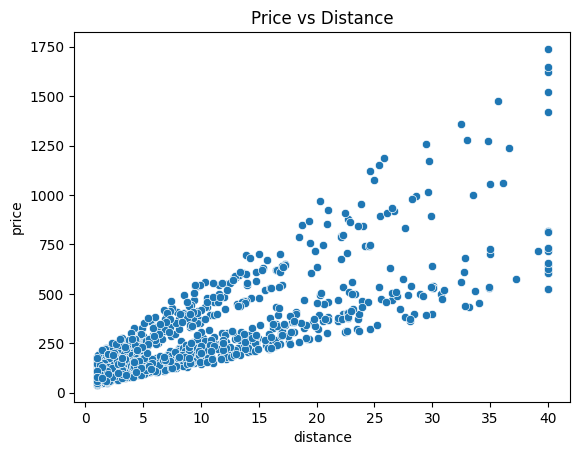

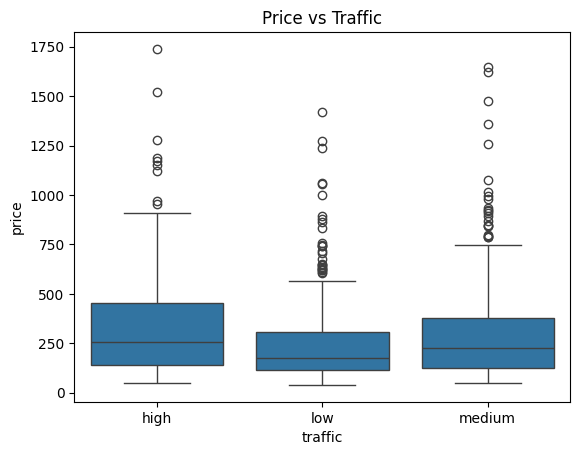

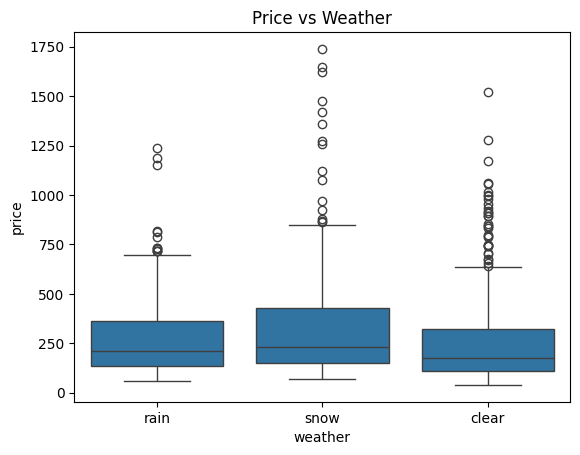

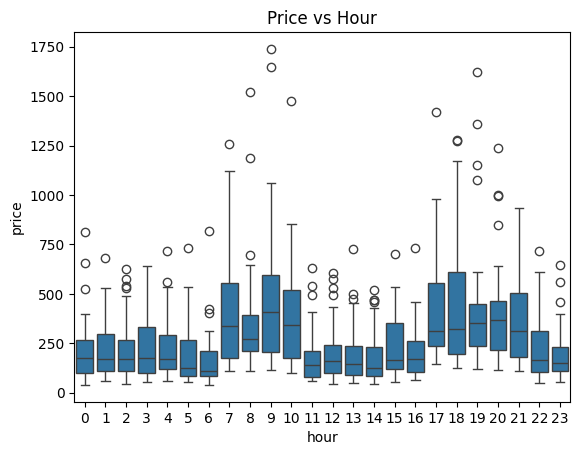

Data validation and exploratory analysis completed successfully.


In [8]:
# Explore relationships between price and other features using scatter plots and box plots

sns.scatterplot(x=df['distance'], y=df['price'])
plt.title('Price vs Distance')
plt.savefig('../outputs/plots/price_vs_distance.png')  # Save the price vs distance scatter plot
plt.show()

sns.boxplot(x=df['traffic'], y=df['price'])
plt.title('Price vs Traffic')
plt.savefig('../outputs/plots/price_vs_traffic.png')  # Save the price vs traffic box plot
plt.show()

sns.boxplot(x=df['weather'], y=df['price'])
plt.title('Price vs Weather')
plt.savefig('../outputs/plots/price_vs_weather.png')  # Save the price vs weather box plot
plt.show()

sns.boxplot(x=df['hour'], y=df['price'])
plt.title('Price vs Hour')
plt.savefig('../outputs/plots/price_vs_hour.png')  # Save the price vs hour box plot
plt.show()

print("Data validation and exploratory analysis completed successfully.")

In [9]:
# Perform feature engineering to create new features that may help the model capture complex patterns in the data

df["is_peak"] = df["hour"].apply(lambda x: 1 if 7 <= x <= 10 or 17 <= x <= 21 else 0)
df["is_night"] = df["hour"].apply(lambda x: 1 if x>=22 or x <= 5 else 0)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

traffic_map= {'low': 1, 'medium': 2, 'high': 3}
df["traffic_encoded"] = df["traffic"].map(traffic_map)

weather_map = {'clear': 1, 'rain': 2, 'snow': 3}
df["weather_encoded"] = df["weather"].map(weather_map)

df["distance_squared"] = df["distance"] ** 2
df["distance_log"] = np.log1p(df["distance"])

df["distance_bucket"] = pd.cut(df["distance"], bins=[0, 5, 12, 25, 35, 50], labels=[0,1,2,3,4]).astype(int)

df["distance_traffic"] = df["distance"] * df["traffic_encoded"]
df["distance_peak"] = df["distance"] * df["is_peak"]
df["traffic_peak"] = df["traffic_encoded"] * df["is_peak"]
df["weather_peak"] = df["weather_encoded"] * df["is_peak"]
df["demand_score"] = (df["is_peak"] * 2 + df["weather_encoded"] * 1.5 + df["traffic_encoded"] * 1.2)

df=df.drop(columns=["traffic", "weather"])

df.to_csv("../data/synthetic_rides_features.csv", index=False)
print("Feature engineering completed and saved as synthetic_rides_features.csv")

Feature engineering completed and saved as synthetic_rides_features.csv
